In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print(df.info())



<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


In [6]:


print(df.describe())



       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [7]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


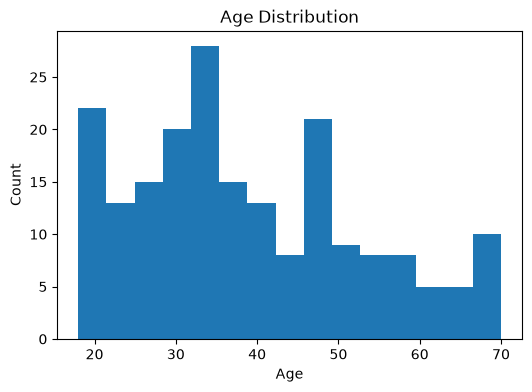

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

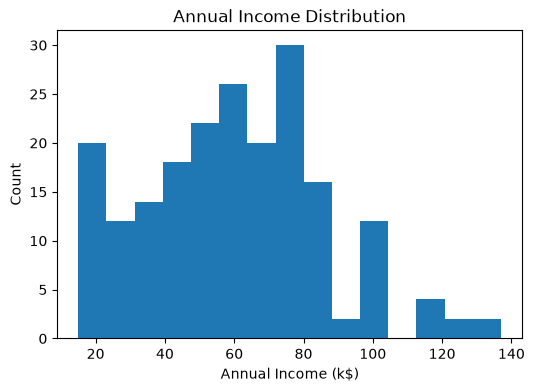

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["Annual Income (k$)"], bins=15)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")
plt.show()

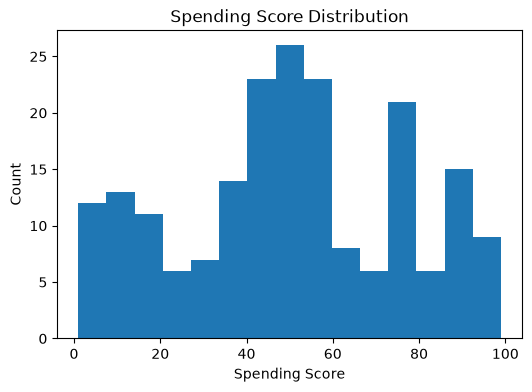

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df["Spending Score (1-100)"], bins=15)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

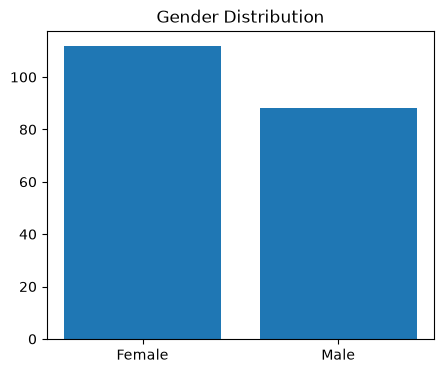

In [11]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(gender_count.index, gender_count.values)
plt.title("Gender Distribution")
plt.show()

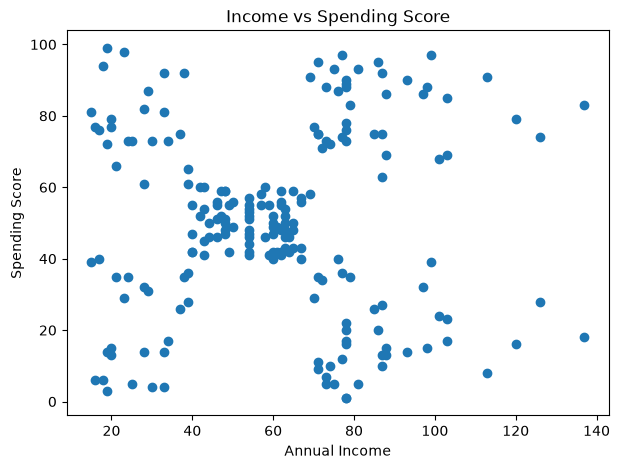

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")

plt.show()

In [13]:
df = df.drop("CustomerID", axis=1)

In [14]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [16]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

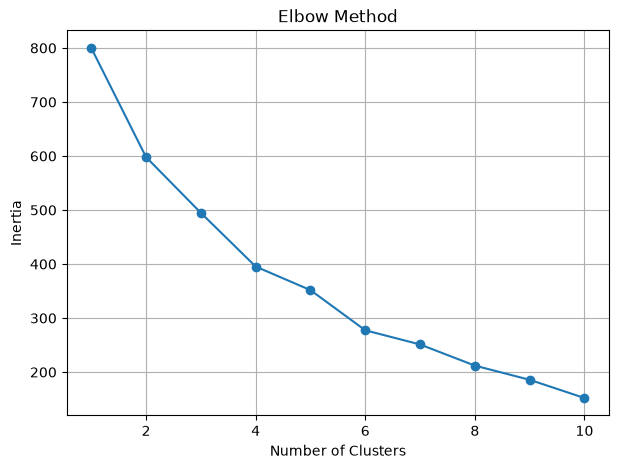

In [17]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

In [19]:
df["Cluster"] = labels

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,4
4,0,31,17,40,4


In [20]:
print(df["Cluster"].value_counts())

Cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64


In [21]:
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.27191023466188324


In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

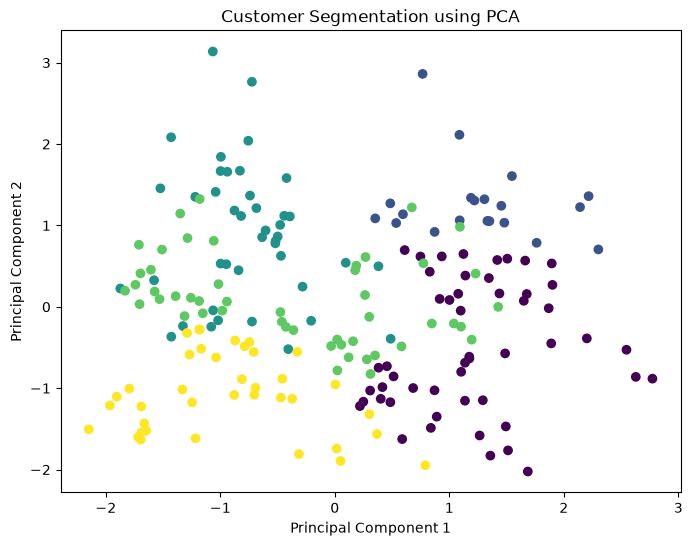

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Customer Segmentation using PCA")

plt.show()

In [24]:
summary = df.groupby("Cluster").agg({

    "Age":"mean",

    "Annual Income (k$)":"mean",

    "Spending Score (1-100)":"mean"

})

print(summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        56.470588           46.098039               39.313725
1        39.500000           85.150000               14.050000
2        28.690476           60.904762               70.238095
3        37.897959           82.122449               54.448980
4        27.315789           38.842105               56.210526


In [25]:
cluster_size = df.groupby("Cluster").size()

print(cluster_size)

Cluster
0    51
1    20
2    42
3    49
4    38
dtype: int64


In [26]:
for cluster in summary.index:

    print("="*40)

    print("Cluster:", cluster)

    print(summary.loc[cluster])

Cluster: 0
Age                       56.470588
Annual Income (k$)        46.098039
Spending Score (1-100)    39.313725
Name: 0, dtype: float64
Cluster: 1
Age                       39.50
Annual Income (k$)        85.15
Spending Score (1-100)    14.05
Name: 1, dtype: float64
Cluster: 2
Age                       28.690476
Annual Income (k$)        60.904762
Spending Score (1-100)    70.238095
Name: 2, dtype: float64
Cluster: 3
Age                       37.897959
Annual Income (k$)        82.122449
Spending Score (1-100)    54.448980
Name: 3, dtype: float64
Cluster: 4
Age                       27.315789
Annual Income (k$)        38.842105
Spending Score (1-100)    56.210526
Name: 4, dtype: float64


| Cluster | Business Name       |
| ------- | ------------------- |
| 0       | Budget Shoppers     |
| 1       | Premium Customers   |
| 2       | Young Trendsetters  |
| 3       | Regular Buyers      |
| 4       | Occasional Visitors |


In [27]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print(centers)

         Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  5.098039e-01  56.470588           46.098039               39.313725
1  1.000000e+00  39.500000           85.150000               14.050000
2  1.000000e+00  28.690476           60.904762               70.238095
3 -1.665335e-16  37.897959           82.122449               54.448980
4  1.665335e-16  27.315789           38.842105               56.210526


In [28]:
df.to_csv(
    "Customer_Segmentation_Result.csv",
    index=False
)

print("File Saved Successfully!")

File Saved Successfully!
